# TP CNNs in Pytorch - part 3

For any remark or suggestion, please feel free to contact me at:

- loic.lefolgoc@telecom-paris.fr

In this session, we will implement and test the method of Gatys et al. for style transfer. The goal is to transform a "content image" so that its style mimics that of a given "style image", while its semantic content remains unchanged.

Similar to the previous TP part, we will leverage the computation of the gradient of a loss function with respect to the image itself (instead of with respect to the weights of a neural network).

We will again use the pre-trained VGG19 architecture to extract deep features from which we will characterize the "content" and the "style" of an image.

There will be two main loss functions:
- a content loss will compare entire feature maps (i.e., at pixel-level) obtained from passing the content image through VGG19 up to some predefined layer, with those obtained from the (modified) image
- a style loss will compare feature map _statistics_ (i.e. mean and Gram matrix) at several intermediate layers; these summary statistics are assumed to capture style because they discard precise spatial localization

More details below. But first, let's load the necessary packages!

In [3]:
import torch
from torch.nn.functional import mse_loss

import torchvision
import torchvision.transforms as T
from torchvision.models import vgg19, VGG19_Weights
from torchvision.models.feature_extraction import create_feature_extractor

from PIL import Image

from tqdm import tqdm

import numpy as np

In [16]:
import matplotlib.pyplot as plt


In [5]:
!pip install kornia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 50.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kornia]2m1/2 [kornia]


In [6]:
import kornia
from kornia.color import rgb_to_lab, lab_to_rgb

/opt/python/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


As usual, you can start by filling the missing parts and debugging on CPU, then restart the environment with a GPU mostly once you are ready to generate results.

In [7]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


For the core algorithmic part, we will deal with images normalized using the usual mean and standard deviation statistics of ImageNet. For visualization, we will denormalize images using the inverse operations. This is already coded for you.

In [8]:
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

normalize = T.Normalize(mean=MEAN, std=STD)
denormalize = T.Normalize(mean=[-m/s for m, s in zip(MEAN, STD)],
                          std=[1/std for std in STD])

We will always resize all images so that the smaller edge is of size 256 using `T.Resize` upon loading. The larger edge will be such that the aspect ratio is preserved.

As a result, the content image and style image can have different dimensions (but of the same order of magnitude). Note that because we are using CNNs, this is not necessarily a problem! In fact, for style transfer, we can work from content and style images of different dimensions. The output image will have the dimensions of the content image.

In [9]:
imsize = 256

In [10]:
def get_preprocess(imsize=None):
    """Generate the transformations that will be applied to images upon loading."""
    preprocess = []
    if imsize:
        # Resize to imsize based on the text cell above
        preprocess.append(T.Resize(size= imsize)) # TO FILL
    preprocess.append(T.ToTensor())
    return T.Compose(preprocess)


def imload(path, imsize=None):
    """Load an image."""
    preprocess = get_preprocess(imsize=imsize)
    image = Image.open(path).convert("RGB")
    return preprocess(image).unsqueeze(0) # unsqueezing adds the batch dimension (B=1)

Let's first download a few images to play with for the lab:
- an image of Shanghai Jiao Tong University's entrance gate, which I think makes for a good content image (feel free to try out other ones!)

Then artistic works which I think make for good style images:
- "Starry Night" by Van Gogh
- "The Great Wave off Kanagawa" by Hokusai
- "Peonies and Butterfly" by Hokusai
- "Evening Snow at Kanbara" by Hiroshige
- Plus a peace dove, for a particularly challenging one (it is kind of a sketch with little except contours)

Style images were downloaded from wikipedia.

In [ ]:
!wget --no-check-certificate -r 'https://drive.google.com/uc?export=download&id=1HeGesJ0JFfZPpxDq8gbuNl0ldg-35HNs' -O content.jpeg
!wget --no-check-certificate -r 'https://drive.google.com/uc?export=download&id=1ydjCxcyWCDnI_FXSRL7mCzlq5dMaYmz5' -O starry_night.jpg

!wget --no-check-certificate -r 'https://drive.google.com/uc?export=download&id=1m23ngfGgtdD0ORvI6jGG9vuaZ6u-KmBy' -O evening_snow.jpg
!wget --no-check-certificate -r 'https://drive.google.com/uc?export=download&id=1bGctO3yNqWWGLZkk0INxN4gZccI0dUvC' -O peonies_butterfly.jpg
!wget --no-check-certificate -r 'https://drive.google.com/uc?export=download&id=1MSTRx3BgPVwxc0JYwOYjA3qDchQg-THa' -O great_wave.jpg

!wget --no-check-certificate -r 'https://drive.google.com/uc?export=download&id=1W1N9kFp3xm3vxEru_g6RVCvnh-hsfcby' -O peace_dove.jpg

will be placed in the single file you specified.

--2026-10-04 13:37:20--  https://drive.google.com/uc?export=download&id=1HeGesJ0JFfZPpxDq8gbuNl0ldg-35HNs
Resolving drive.google.com (drive.google.com)... 142.251.39.110, 2a00:1450:4007:810::200e
Connecting to drive.google.com (drive.google.com)|142.251.39.110|:443... connected.
HTTP request sent, awaiting response... 

303 See Other
Location: https://drive.usercontent.google.com/download?id=1HeGesJ0JFfZPpxDq8gbuNl0ldg-35HNs&export=download [following]
--2026-10-04 13:37:21--  https://drive.usercontent.google.com/download?id=1HeGesJ0JFfZPpxDq8gbuNl0ldg-35HNs&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.16.225, 2a00:1450:4007:812::2001
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.16.225|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 91354 (89K) [image/jpeg]
Saving to: ‘content.jpeg’

content.jpeg        100%[===================>]  89.21K  --.-KB/s    in 0.009s  

2026-10-04 13:37:22 (9.29 MB/s) - ‘content.jpeg’ saved [91354/91354]

FINISHED --2026-10-04 13:37:22--
Total wall clock time: 1.2s
Downloaded: 1 files, 89K in 0.009s (9.29 MB/s)
will be placed in the single file you specified.

--2026-10-04 13:37:22--  https://drive.google.com/uc?export=download&id=1ydjCxcyWCDnI_FXSRL7mCzlq5dMaYm

Let's load and visualize those images:

In [13]:
SJTU_gate = imload(path='content.jpeg', imsize=imsize).to(device)

starry_night = imload(path='starry_night.jpg', imsize=imsize).to(device)
evening_snow = imload(path='evening_snow.jpg', imsize=imsize).to(device)
peonies_butterfly = imload(path='peonies_butterfly.jpg', imsize=imsize).to(device)
great_wave = imload(path='great_wave.jpg', imsize=imsize).to(device)
peace_dove = imload(path='peace_dove.jpg', imsize=imsize).to(device)

In [ ]:
content_image = SJTU_gate.clone().detach()

# Feel free to try out different style images
style_image = starry_night.clone().detach()

Content image:

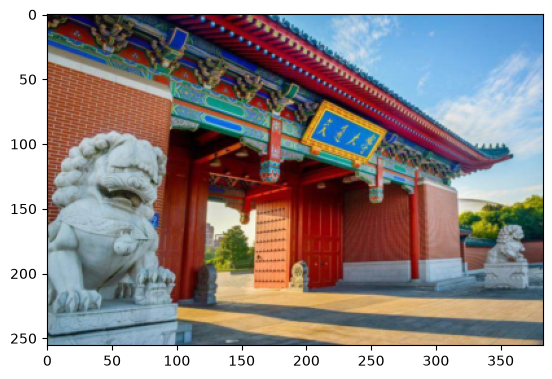

In [17]:
plt.imshow(content_image.clamp_(0.0, 1.0).squeeze(0).permute(1, 2, 0).cpu())

Style image:

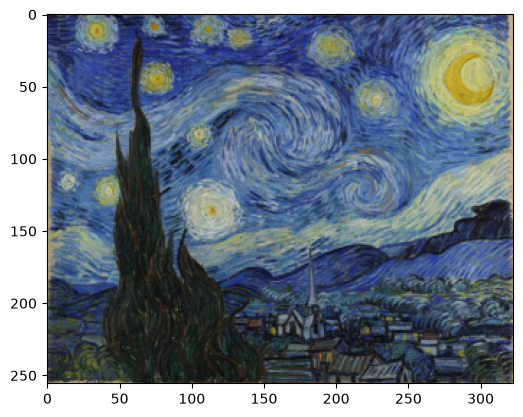

In [18]:
plt.imshow(style_image.clamp_(0.0, 1.0).squeeze(0).permute(1, 2, 0).cpu())

# 1. Gatys's method

Image normalization:

In [65]:
content_image = normalize(content_image)
style_image = normalize(style_image)

Let's load the VGG19 model with trained weights:

In [20]:
vgg = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features
vgg.eval()
vgg.to(device)
for param in vgg.parameters():
    param.requires_grad = False #cancel the updates of the weights of VGG

0.6%

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /home/onyxia/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100.0%


Finally, we are going to define a feature extractor `feature_extractor`. It is in charge of conveniently returning in a dictionary feature maps from several requested layers of VGG19, (computed on any given image) when called as `feature_extractor(image)`.

Note that we can backpropagate through `feature_extractor`. Use `feature_extractor(image.detach())` if necessary.

In [66]:
# Defines the return nodes for feature extraction
# These nodes correspond to the layers of VGG19 we want to use for style and content features
# The numbers correspond to the indices of the layers in the VGG19 model
# The readable names are how the keys will be named in the dictionary when calling
#   feature_extractor(image)
return_nodes = {'1': 'relu_1_1',
                '6': 'relu_2_1',
                '11': 'relu_3_1',
                '20': 'relu_4_1',
                '22': 'relu_4_2',
                '29': 'relu_5_1'}

feature_extractor = create_feature_extractor(model= vgg, return_nodes= return_nodes) # LINE TO FILL

# Here are the layers we will use for style and content
style_nodes = ['relu_1_1', 'relu_2_1', 'relu_3_1', 'relu_4_1', 'relu_5_1']
content_nodes = ['relu_4_2']

Now we are getting to the parts where you have to do the work! Let's start with the content loss. The content loss is simply the sum of mse losses (using `mse_loss`) over the feature maps of the selected layers:

In [67]:
def compute_content_loss(features, targets, nodes):
    """Calculate Content Loss.

    features: the modified image's dictionary of feature maps
    targets: the content image's dictionary of feature maps
    nodes: the selected layers
    """
    content_loss = 0
    for node in nodes:
        content_loss += torch.sum(mse_loss(features[node], target= targets[node])) #add mse loss btw modified image and target, on wanted nodes (=layers)

    return content_loss

Next we are going to implement the building blocks for two variants of style losses:
- a function that turns feature maps (at a given layer) into a Gram matrix
- a function that turns feature maps into a mean vector and a covariance matrix

The idea being that the style loss will measure either
- the mean square error between Gram matrices of the modified image vs. style image
- the MSE between means of the modified image vs. style image + the MSE between covariance matrices of the modified image vs. style image

Noting `x` a (C, H, W) stack of C feature maps, we call the Gram matrix of `x` the (C,C) matrix `G` defined as $$G_{i,j}=\frac{1}{HW}\sum_{h,w} x(i,h,w)^T x(j,h,w)$$

The mean of `x` is the C-dimensional vector `mu` such that $$\mu_i=\frac{1}{HW}\sum_{h,w} x(i,h,w)$$

The covariance matrix of `x` is the (C,C) matrix `S` defined as $$S_{i,j}=\frac{1}{HW}\sum_{h,w} \left(x(i,h,w)-\mu_i\right)^T \left(x(j,h,w)-\mu_j\right)$$

Covariance and Gram matrices here differ by a centering operation.

We implement these quantities in what follows (note that the tensors we manipulate below have an additional batch dimension B)

In [68]:
def gram(x):
    """Transfer a feature to gram matrix.
    Input x: (B, C, H, W) tensor - a stack of feature maps
    Output:
    """
    b, c, h, w = x.size()

    features = x.view(b, c, h * w)
    gram = torch.bmm(features, features.transpose(1, 2))/(h*w)

    return gram


def statistics(x):
    """Compute first and second order statistics of the feature maps"""
    b, c, h, w = x.size()
    f = x.view(b, c, h * w)

    # Mean over spatial locations (so last dimension: dim=2)
    mu = f.mean(dim=2)

    # Covariance matrix
    centered = f - mu.unsqueeze(2)
    S = torch.bmm(centered, centered.transpose(1, 2)) / (h * w - 1)

    return mu, S

With these building blocks in place, we can implement the style loss:

In [69]:
def compute_style_loss(features, targets, nodes, loss_type='Gram'):
    """
    Compute style loss
      loss_type: 'Gram' or 'MuSigma'

    features: the modified image's dictionary of feature maps
    targets: the style image's dictionary of feature maps
    nodes: the selected layers
    """
    if loss_type == 'Gram':
        gram_loss = 0
        # Accumulate MSE terms for every node in nodes
        # where each MSE term measures the discrepancy between Gram matrices
        # obtained from features vs. targets
        for node in nodes:
          gram_loss += mse_loss(gram(features[node]), gram(targets[node]))

        return gram_loss

    elif loss_type == 'MuSigma':
        mu_loss = sigma_loss = 0
        # Accumulate MSE terms for every node in nodes
        # where each MSE term measures the discrepancy between mean vectors
        # obtained from features vs. targets; respectively between covariance
        # matrices from features vs. targets
        for node in nodes:
          mu_target, S_target= statistics(targets[node])
          mu_feature, S_feature= statistics(features[node])
          mu_loss += mse_loss(mu_target, mu_feature)
          sigma_loss += mse_loss(S_target, S_feature)

        return mu_loss + sigma_loss

    else:
        return None

We will use an additional regularizer, the total variation loss, that encourages modified images to look more like natural images:

In [70]:
def compute_tv_loss(x):
    """Calculate Total Variation Loss."""
    tv_loss = torch.mean(torch.abs(x[:, :, :, :-1] - x[:, :, :, 1:]))
    tv_loss += torch.mean(torch.abs(x[:, :, :-1, :] - x[:, :, 1:, :]))
    return tv_loss

All good! Now we can move on to solving the style transfer task, which we frame as an optimization problem over the pixels of the input image. The input image should minimize a combination of content loss, style loss, and total variation loss.

We initialize the input image from a mix of
- the content image
- a random noise image

In [71]:
noise_ratio = 0.5

# Create a random noise image with torch.rand_like; move it to the device device
input_image = torch.rand_like(content_image)

# Modify this image to be noise ratio * itself + (1 - noise ratio) * the content image
# Note: We don't want to backpropagate onto the content image! Use detach()!
input_image = noise_ratio * input_image + (1-noise_ratio) * content_image

We will use LBFGS as an optimizer, it is more effective for this style transfer formulation than Adam or AdamW; but it is also a bit slower...

In [72]:
# define the optimizer so that it knows that the "parameters" to optimize are the input image
optimizer = torch.optim.LBFGS([input_image.requires_grad_(True)]) # Note, we have to set requires_grad flag to true so we have access to the gradients associated to the input image, after backpropagation from losses

Next we can write and run the optimization loop:

In [73]:
# Feel free to experiment with different loss weights, these defaults should work
# reasonably well:
content_loss_weight = 1
style_loss_weight = 50.0
tv_loss_weight = 0.5 #total variation loss (additionnal to regularize images)

In [74]:
# I'm setting a smaller number of iterations for speed;
# results can be visually improved for some style images by increasing that number x2 or x4...
num_iteration = 25

Now we can, in the optimization loop, compute the losses and call backward. When stepping, the optimizer will automatically update the image! effectively creating a new image with the style transferred.

In [75]:
for i in tqdm(range(num_iteration), desc='Stylization'):
    # LBGFS needs the optimization step to be implemented via a closure function
    # This is because within a given step it can make multiple sub-iterations,
    # trying different jumps in parameter-space along a given search direction
    def closure():
        """Closure function."""
        optimizer.zero_grad()

        # Extract feature dictionaries of the content image, style image, and
        # input image. Note that we do not want to backprop by mistake through
        # content and style images, only through to the input image!!
        content_features = feature_extractor(content_image)
        style_features = feature_extractor(style_image)
        input_features = feature_extractor(input_image) #initialized as content_image + noise

        # Compute the content, style and total variation losses
        # For the style loss, feel free to use either Gram or MuSigma variant....
        content_loss = compute_content_loss(content_features, input_features, nodes = content_nodes)
        style_loss = compute_style_loss(style_features, input_features, loss_type = "Gram", nodes= style_nodes)
        tv_loss = compute_tv_loss(input_image)

        # Compute the total loss (the weighted sum of the three terms weighted
        # by their respective weights defined above)
        total_loss = content_loss_weight * content_loss + style_loss_weight * style_loss + tv_loss_weight * tv_loss

        # Backward and return loss
        total_loss.backward()
        return total_loss

    # Optimization step:
    optimizer.step(closure)

Stylization: 100%|██████████| 25/25 [00:46<00:00,  1.85s/it]


Let's look at the output image. Not bad I think? You can try out for different style images! it should work fairly well on all but the peace dove.

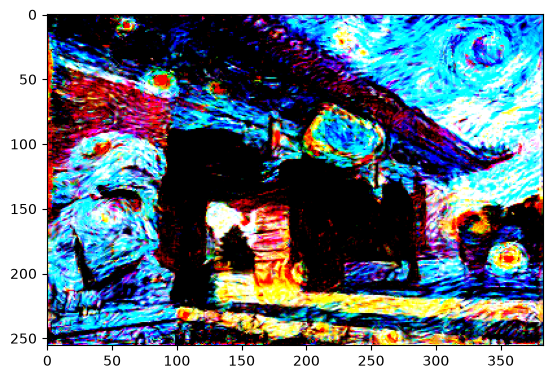

In [76]:
plt.imshow(denormalize(input_image).clamp_(0.0, 1.0).squeeze(0).permute(1, 2, 0).detach().cpu())

# 2. Preserving the color palette (somewhat)

You have probably noticed that the style transfer also changed the color palette of the output image compared to the content image. Sometimes we want to change the style of the content image but preserve its color palette. We will implement a very simple method to do so.

Our strategy will be to transfer the color palette of the content image onto the style image, prior to doing the style transfer as in the previous part.

We will implement the simplest approach to transfer the color palette. __Make sure to reload content and style images so as not to inherit an already normalized image before doing the color palette transfer__. For this part, I suggest to start with "Starry Night" for the style image as the color transfer and subsequent style transfer works best for this one.

In [77]:
content_image = SJTU_gate.clone().detach()

style_image = starry_night.clone().detach()

The approach relies on the computation of symmetric positive matrix square roots and inverse square roots. A simple way to obtain one is to diagonalize the (symmetric positive) matrix $S$ in an orthonormal basis: $$S = U \Lambda U^T$$ where the matrix of eigenvectors $U$ and the diagonal matrix of eigenvalues $\Lambda$ can be obtained through a call to `torch.linalg.eigh` (look up the documentation).

You can then obtain a square root and inverse square root as $$\sqrt{S} = U\sqrt{\Lambda} U^T$$ and $$\sqrt{S}^{-1} = U\sqrt{\Lambda}^{-1} U^T$$
where $\sqrt{\Lambda}$ is the diagonal matrix with diagonal entries set to the square root of the diagonal entries of $\Lambda$.

In [78]:
def matrix_sqrt(matrix: torch.Tensor) -> torch.Tensor:
    vals, vecs = torch.linalg.eigh(matrix)
    vals_sqrt = torch.sqrt(vals)
    matrix_sqrt = vecs @ torch.diag_embed(vals_sqrt) @ vecs.transpose(-1, -2)

    return matrix_sqrt

def matrix_isqrt(matrix: torch.Tensor) -> torch.Tensor:
    vals, vecs = torch.linalg.eigh(matrix)
    vals_isqrt = vals ** (-0.5)
    matrix_isqrt = vecs @ torch.diag_embed(vals_isqrt) @ vecs.transpose(-1, -2)

    return matrix_isqrt

We can now implement the color palette transfer in the routine `color_transfer(source, target)`, which transfers the colors of the source image onto the target image as follows:
- first compute $C$-dimensional vectors `mu_s` and `mu_t` (for source and target images with $C$ channels) corresponding to the mean pixel intensity of the source image, resp. target image
- next center the intensities of the source image (resp. target image) by subtracting their respective mean intensity vectors
- then compute the $C\times C$ covariance matrix $\Sigma_s$ of intensity vectors of the source image i.e., $\Sigma_s(i,j)=(1/HW) \sum_{h,w} (I_s(h,w)-\mu_s)(I_s(h,w)-\mu_s)^T$
- same for the covariance matrix $\Sigma_t$ of the target image
- finally, restandardize the source image's intensities using the target image's mean and covariance: $$out = \sqrt{\Sigma_t}\sqrt{\Sigma_s}^{-1}(I_s - \mu_s) + \mu_t$$

In [79]:
def color_transfer(source, target):
    b, c, h, w = source.size()
    # mean pixel values
    mu_s = source.view(b, c, h * w).mean(dim=2, keepdim=True) 
    mu_t = target.view(b, c, h * w).mean(dim=2, keepdim=True)

    # centered source and target images
    source_c = source.view(b, c, h * w) - mu_s
    target_c = target.view(b, c, h * w) - mu_t

    # covariances
    Sigma_s = torch.bmm(source_c, source_c.transpose(1,2))/(h*w)
    Sigma_t = torch.bmm(target_c, target_c.transpose(1,2))/(h*w)

    # inverse square root of source covariance, square root of target covariance
    istd_s = matrix_isqrt(Sigma_s)
    std_t = matrix_sqrt(Sigma_t)

    # recolorized output
    return (torch.bmm(torch.bmm(std_t, istd_s), source_c) + mu_t).view(b, c, h, w)

We can now test the style transfer. Note that in image processing, there are several color spaces beyond RGB, that sometimes are more adapted to such or such color processing. One such space is LAB (look it up on wikipedia!).

We can test the color transfer in LAB or in RGB, up to you which one you prefer and go with. You can use kornia's `rgb_to_lab` and `lab_to_rgb` to go back and forth from the original color space (RGB) to LAB. Ultimately, we end up with a recolored style image `style_image_recolored` always in RGB space.

In [80]:
color_space = 'lab' # 'rgb'

if color_space == 'lab':
  style_image = torch.nn.functional.interpolate(
    style_image,
    size=content_image.shape[-2:],
    mode='bilinear',
    align_corners=False) #redimensionate style image so same shape that content one

  content_lab = rgb_to_lab(content_image)
  style_lab = rgb_to_lab(style_image)

  style_lab = color_transfer(style_lab, content_lab)
  style_image_recolored = lab_to_rgb(style_lab, clip=True)

elif color_space == 'rgb':
  # we are doing the color transfer directly in the original color space then clamping back to the [0,1] range just in case
  style_image_recolored = torch.clamp(style_image, min=0., max=1.)

else:
  print('Not implemented!!')

Visualize the content image, recolored style image, and original style image. Decide the variant of color transfer that you prefer!

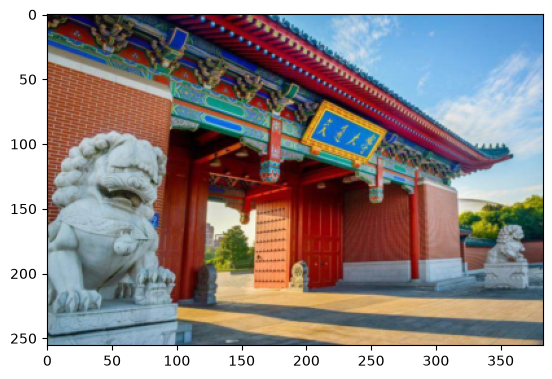

In [81]:
import matplotlib.pyplot as plt
plt.imshow(content_image.clamp_(0.0, 1.0).squeeze(0).permute(1, 2, 0).cpu())

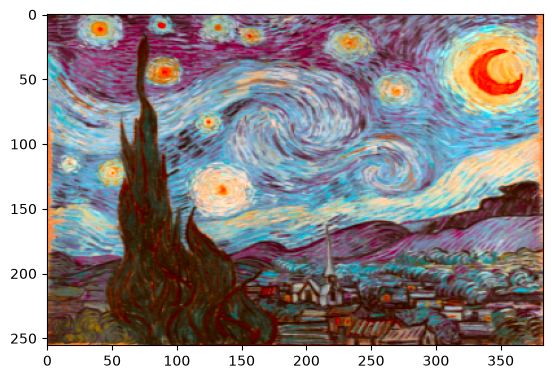

In [82]:
plt.imshow(style_image_recolored.clamp_(0.0, 1.0).squeeze(0).permute(1, 2, 0).cpu())

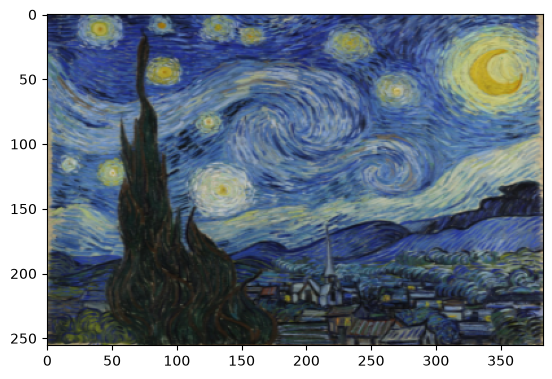

In [83]:
plt.imshow(style_image.clamp_(0.0, 1.0).squeeze(0).permute(1, 2, 0).cpu())

Next we normalize the relevant images using ImageNet statistics, before doing the style transfer:

In [84]:
content_image = normalize(content_image)
style_image_recolored = normalize(style_image_recolored)

Finally, I leave it to you to do the style transfer as before. __If you copy-paste code, make sure to use the recolorized style image as style image (and not the original one)__.

In [85]:
# Copy-paste code/cells or rewrite everything so as to do the style transfer (using the recolorized style image)
# You need to reinitialize an input_image, the optimizer, redo the optimization, etc.


input_image = torch.rand_like(content_image)
input_image = noise_ratio * input_image + (1-noise_ratio) * content_image

style_image= style_image_recolored

optimizer = torch.optim.LBFGS([input_image.requires_grad_(True)]) 

for i in tqdm(range(num_iteration), desc='Stylization'):
    # LBGFS needs the optimization step to be implemented via a closure function
    # This is because within a given step it can make multiple sub-iterations,
    # trying different jumps in parameter-space along a given search direction
    def closure():
        """Closure function."""
        optimizer.zero_grad()

        # Extract feature dictionaries of the content image, style image, and
        # input image. Note that we do not want to backprop by mistake through
        # content and style images, only through to the input image!!
        content_features = feature_extractor(content_image)
        style_features = feature_extractor(style_image)
        input_features = feature_extractor(input_image) #initialized as content_image + noise

        # Compute the content, style and total variation losses
        # For the style loss, feel free to use either Gram or MuSigma variant....
        content_loss = compute_content_loss(content_features, input_features, nodes = content_nodes)
        style_loss = compute_style_loss(style_features, input_features, loss_type = "Gram", nodes= style_nodes)
        tv_loss = compute_tv_loss(input_image)

        # Compute the total loss (the weighted sum of the three terms weighted
        # by their respective weights defined above)
        total_loss = content_loss_weight * content_loss + style_loss_weight * style_loss + tv_loss_weight * tv_loss

        # Backward and return loss
        total_loss.backward()
        return total_loss

    # Optimization step:
    optimizer.step(closure)
# TO FILL BY STUDENTS

Stylization: 100%|██████████| 25/25 [00:47<00:00,  1.90s/it]


Let's look at the output image. The color palette is not perfectly preserved but it is not too bad either (at least for Van Gogh's Starry Night as the style image):

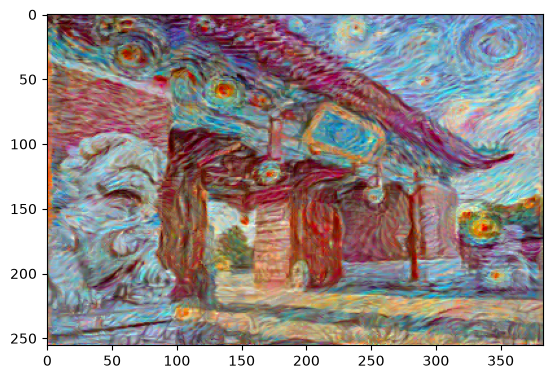

In [86]:
plt.imshow(denormalize(input_image).clamp_(0.0, 1.0).squeeze(0).permute(1, 2, 0).detach().cpu())

# 3. Completely optional: try to make it work for peace dove style image!

If you have got time left, you can try to make the style transfer work for the peace dove. Here we assume we want to output an image with the same color palette as the peace dove. It is difficult because it is kind of a sketch, mostly black and white; whereas the content image is colorful.

One idea is to first compute a contour image from the content image, then to apply the style transfer to this contour image. kornia can help here again. I leave it to you to be creative!

__This part does not count towards the grade on the lab. Except if it is successfully done, then add a bonus of 2 points (on a 0 to 10 scale). But not doing it should not prevent the student from getting full points on this lab part 3.__

# Evaluation

To evaluate this lab part, you should rate the code for
- 1) `compute_content_loss` : 1 points
- 2) `gram` : 1 point
- 3) `statistics`: 1 points
- 4) `compute_style_loss` : 1 point
- 5) initializing `input_image` : 1 point
- 6) Writing the optimization loop to do style transfer : 1 point
- 7) `matrix_sqrt` and `matrix_isqrt` : 1 point
- 8) `color_transfer` : 1 point
- 9) creating `style_image_recolored`, both LAB and RGB space variants : 1 point
- 10) Doing the style transfer while preserving the color palette somewhat on Van Gogh's Starry Night : 1 point
- BONUS: Style transfer works somewhat on peace dove : 2 points


Total capped at 10 points.

# References

Parts of this lab have been inspired by third-party material (references acknowledged only in the correction :-))